In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import matplotlib.pyplot as plt
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras import Model
import tensorflow as tf
import numpy as np
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.models import load_model
import os
from sklearn.metrics import confusion_matrix
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve
import keras
from tensorflow.keras import layers, Sequential
from PIL import Image
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import accuracy_score
import pandas as pd
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.utils import plot_model
from tensorflow.keras import regularizers
from tensorflow.keras.applications import VGG16
from scipy.stats import mode
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras import layers, models

In [3]:
from zipfile import ZipFile

data_path = '/content/drive/MyDrive/real and fake images.zip'

with ZipFile(data_path, 'r') as zip:
    zip.extractall()
    print('The data set has been extracted.')

The data set has been extracted.


In [4]:
# Assuming your real and fake images are in different directories
real_images_directory = "/content/real and fake images/ffhq images"
fake_images_directory = "/content/real and fake images/dcgan images"

# Get a list of image files in the real and fake directories
real_image_files = [f for f in os.listdir(real_images_directory) if f.endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff'))]
fake_image_files = [f for f in os.listdir(fake_images_directory) if f.endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff'))]

# Load and preprocess real and fake images
def preprocess_image(image_path):
    img = Image.open(image_path)
    img = img.resize((256, 256))  # Resize the image as needed
    img = np.array(img)  # Convert to numpy array
    img = img / 255.0  # Normalize pixel values
    return img

real_images = [preprocess_image(os.path.join(real_images_directory, img)) for img in real_image_files]
fake_images = [preprocess_image(os.path.join(fake_images_directory, img)) for img in fake_image_files]

# Create labels (1 for real, 0 for fake)
real_labels = np.ones(len(real_images))
fake_labels = np.zeros(len(fake_images))

# Combine images and labels
images = np.concatenate((real_images, fake_images))
labels = np.concatenate((real_labels, fake_labels))

In [5]:
# Split the dataset into train and test sets,
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.3, random_state=7)

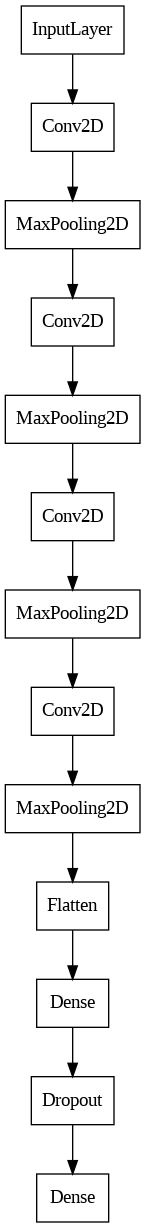

In [6]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auroc')])


# Plot the model architecture
plot_model(model, to_file='model_architecture.png', show_shapes=False, show_layer_names=False)












In [7]:
# Train the model with callbacks, mini-batch size, and specified momentum
history = model.fit(X_train, y_train,
                    epochs=100,
                    validation_data=(X_test, y_test),
                    batch_size=128,  # Adding mini-batch size
                    verbose=2)

Epoch 1/100
3/3 - 26s - loss: 0.9831 - accuracy: 0.5406 - auroc: 0.5626 - val_loss: 0.7724 - val_accuracy: 0.5000 - val_auroc: 0.2929 - 26s/epoch - 9s/step
Epoch 2/100
3/3 - 1s - loss: 0.7418 - accuracy: 0.4947 - auroc: 0.4609 - val_loss: 0.6804 - val_accuracy: 0.5000 - val_auroc: 0.8474 - 790ms/epoch - 263ms/step
Epoch 3/100
3/3 - 1s - loss: 0.6719 - accuracy: 0.5689 - auroc: 0.7387 - val_loss: 0.6406 - val_accuracy: 0.5328 - val_auroc: 0.8694 - 696ms/epoch - 232ms/step
Epoch 4/100
3/3 - 1s - loss: 0.6574 - accuracy: 0.5371 - auroc: 0.6589 - val_loss: 0.9069 - val_accuracy: 0.5000 - val_auroc: 0.8546 - 716ms/epoch - 239ms/step
Epoch 5/100
3/3 - 1s - loss: 0.7751 - accuracy: 0.5618 - auroc: 0.6673 - val_loss: 0.6375 - val_accuracy: 0.5820 - val_auroc: 0.9086 - 705ms/epoch - 235ms/step
Epoch 6/100
3/3 - 1s - loss: 0.6266 - accuracy: 0.6714 - auroc: 0.8877 - val_loss: 0.5768 - val_accuracy: 0.8852 - val_auroc: 0.9454 - 699ms/epoch - 233ms/step
Epoch 7/100
3/3 - 1s - loss: 0.5167 - accura

4/4 [==============================] - 2s 259ms/step


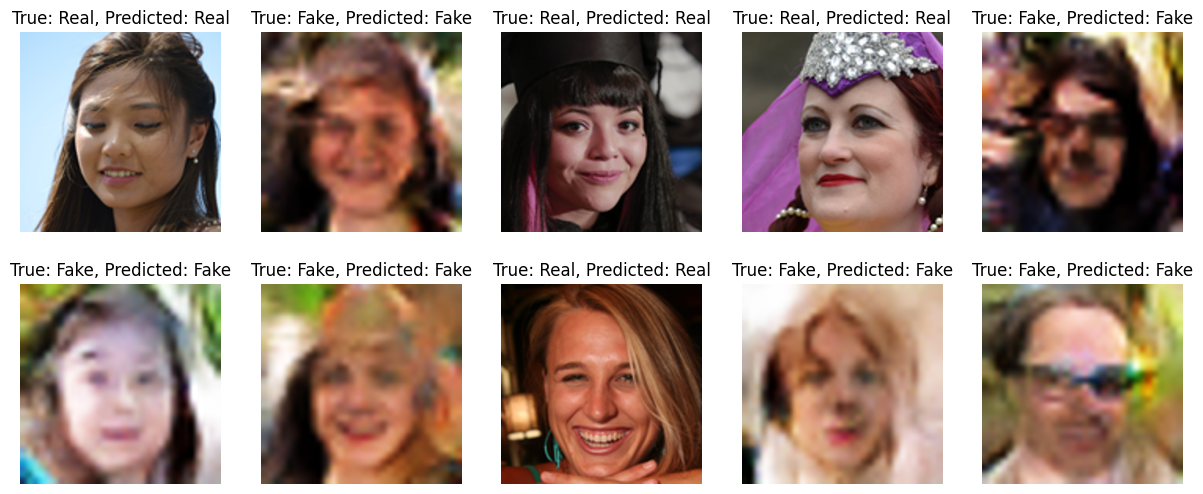

In [8]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Visualize some random images along with their predicted labels
num_samples_to_visualize = 10
num_rows = 2
num_cols = num_samples_to_visualize // num_rows

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 6))

for i in range(num_rows):
    for j in range(num_cols):
        idx = np.random.randint(len(X_test))
        image = X_test[idx]
        true_label = "Real" if y_test[idx] == 1 else "Fake"
        predicted_label = "Real" if y_pred[idx] >= 0.5 else "Fake"

        axes[i, j].imshow(image)
        axes[i, j].set_title(f"True: {true_label}, Predicted: {predicted_label}")
        axes[i, j].axis('off')

plt.show()

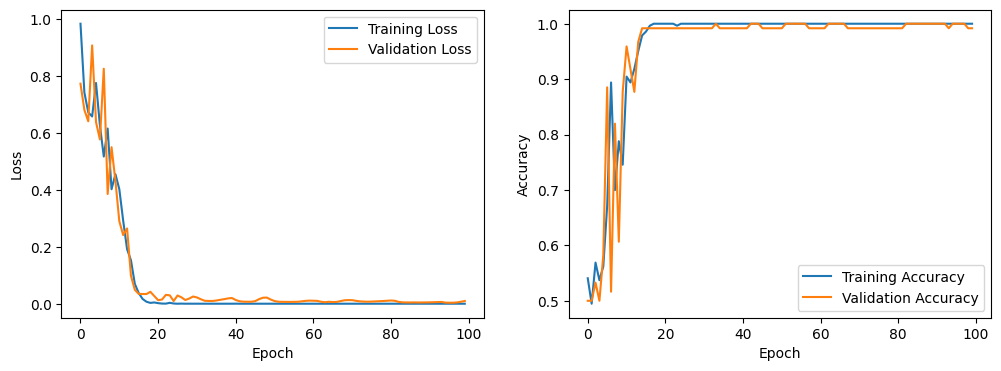

In [9]:

# Create a figure with a size of 12x4 inches
plt.figure(figsize=(12, 4))

# Plotting training and validation loss
plt.subplot(1, 2, 1)  # Create a subplot for loss
plt.plot(history.history['loss'], label='Training Loss')  # Plot training loss
plt.plot(history.history['val_loss'], label='Validation Loss')  # Plot validation loss
plt.xlabel('Epoch')  # Label for the x-axis
plt.ylabel('Loss')  # Label for the y-axis
plt.legend()  # Add a legend to differentiate between training and validation loss

# Plotting training and validation accuracy
plt.subplot(1, 2, 2)  # Create a subplot for accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')  # Plot training accuracy
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')  # Plot validation accuracy
plt.xlabel('Epoch')  # Label for the x-axis
plt.ylabel('Accuracy')  # Label for the y-axis
plt.legend()  # Add a legend to differentiate between training and validation accuracy

# Display the plots
plt.show()


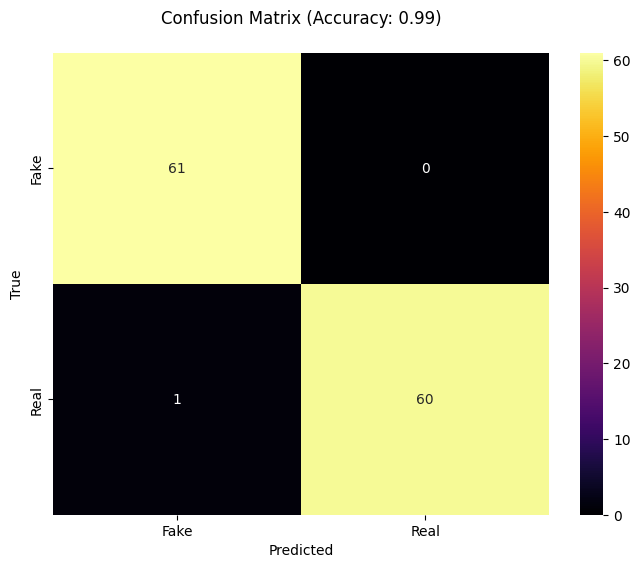

In [10]:

y_pred_binary = (y_pred > 0.5).astype(int)



# Generate a confusion matrix
confusion = confusion_matrix(y_test, y_pred_binary)

# Plot the confusion matrix with labels and numbers
plt.figure(figsize=(8, 6))
sns.heatmap(confusion, annot=True, fmt='d', cmap='inferno', cbar=True)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks([0.5, 1.5], ['Fake', 'Real'])
plt.yticks([0.5, 1.5], ['Fake', 'Real'])
plt.title(f'Confusion Matrix (Accuracy: {accuracy_score(y_test, y_pred_binary):.2f})\n')
plt.show()

In [11]:
classification_rep = classification_report(y_test, y_pred_binary)
print(classification_rep)

              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99        61
         1.0       1.00      0.98      0.99        61

    accuracy                           0.99       122
   macro avg       0.99      0.99      0.99       122
weighted avg       0.99      0.99      0.99       122



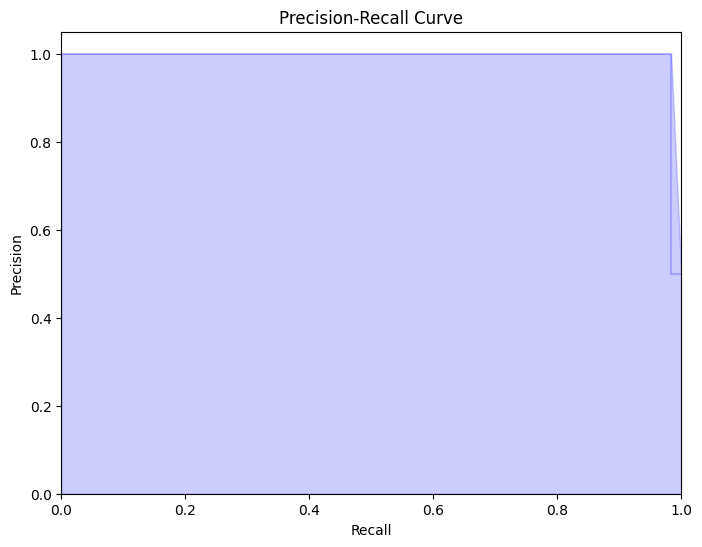

In [12]:
precision, recall, _ = precision_recall_curve(y_test, y_pred_binary)

plt.figure(figsize=(8, 6))
plt.step(recall, precision, color='b', alpha=0.2, where='post')
plt.fill_between(recall, precision, alpha=0.2, color='b')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.show()

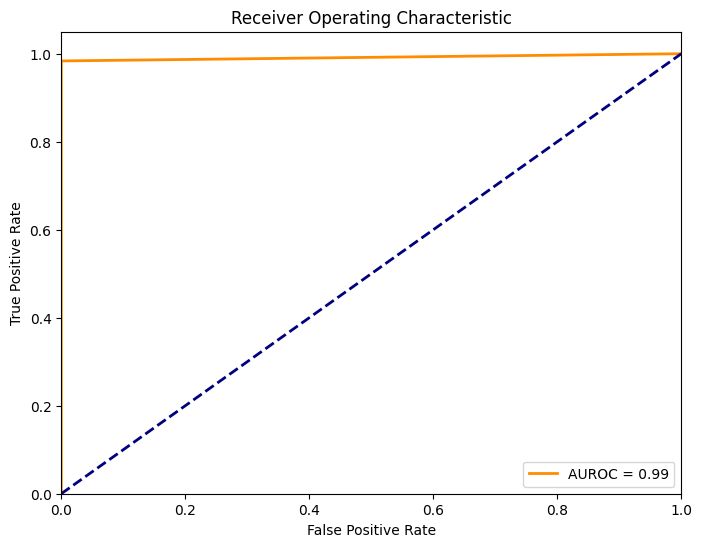

In [13]:
# Compute the AUROC score for each class (assuming binary classification)
fpr, tpr, _ = roc_curve(y_test, y_pred_binary)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='AUROC = %0.2f' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()


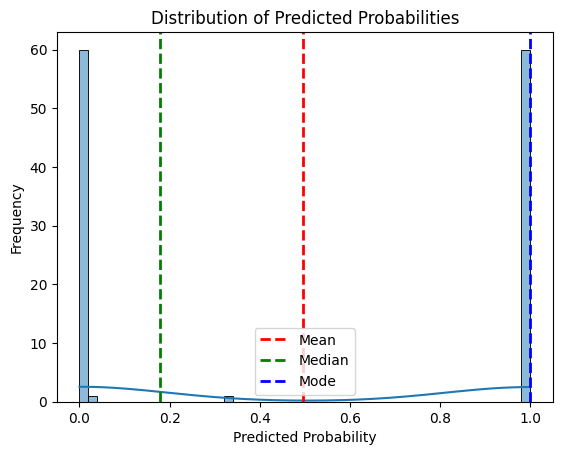

In [14]:
# Flatten the predicted probabilities
y_pred_flat = y_pred.flatten()

# Calculate mean, median, and mode of predicted probabilities
mean_prob = np.mean(y_pred_flat)
median_prob = np.median(y_pred_flat)
mode_result = mode(y_pred_flat)

# If there are multiple modes, choose the first one
if isinstance(mode_result.mode, np.ndarray):
    mode_prob = mode_result.mode[0]
else:
    mode_prob = mode_result.mode

# Plot the distribution of predicted probabilities with mean, median, and mode lines
sns.histplot(y_pred_flat, kde=True, bins=50)
plt.axvline(mean_prob, color='red', linestyle='dashed', linewidth=2, label='Mean')
plt.axvline(median_prob, color='green', linestyle='dashed', linewidth=2, label='Median')
plt.axvline(mode_prob, color='blue', linestyle='dashed', linewidth=2, label='Mode')

plt.title('Distribution of Predicted Probabilities')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.legend()
plt.show()